In [1]:
import pandas as pd

# 1. Load your data
df = pd.read_csv('DFW_2026.csv', low_memory=False)

# 2. Count TOTAL homes sold by each broker
total_homes = df.groupby('list_broker_name_1').size().rename('Total_Listings')

# 3. Filter the data to ONLY look at new construction (2025 & 2026)
new_construction_df = df[df['yearBuilt'].isin([2025, 2026])]

# 4. Count NEW homes sold by each broker
new_homes = new_construction_df.groupby('list_broker_name_1').size().rename('New_Listings')

# 5. Combine these two counts into one table
builder_check = pd.concat([total_homes, new_homes], axis=1).fillna(0)

# 6. Calculate the percentage: (New Listings / Total Listings) * 100
builder_check['Percent_New'] = (builder_check['New_Listings'] / builder_check['Total_Listings']) * 100

# 7. Find the Homebuilders! 
# Let's say anyone with at least 5 listings, where 90%+ are new, is a builder.
homebuilders = builder_check[
    (builder_check['Total_Listings'] >= 5) & 
    (builder_check['Percent_New'] >= 90)
]

# Sort them from largest to smallest to see the biggest builders
homebuilders = homebuilders.sort_values('Total_Listings', ascending=False)

print(homebuilders)

                                Total_Listings  New_Listings  Percent_New
list_broker_name_1                                                       
Turner Mangum,LLC                         3268        2951.0    90.299878
Meritage Homes Realty                     1405        1356.0    96.512456
Jeanette Anderson Real Estate              980         887.0    90.510204
D.R. Horton, AMERICA'S Builder             823         802.0    97.448360
Escape Realty                              593         568.0    95.784148
HIGHLAND HOMES REALTY                      411         378.0    91.970803
Alexander Properties                       356         336.0    94.382022
Keller Williams Realty Lone St             175         172.0    98.285714
Master Key Realty                           32          32.0   100.000000
Bransom Real Estate                         21          20.0    95.238095


In [3]:
# 1. Load your data with the low_memory fix to prevent the red warning
file_name = 'DFW_2026.csv'
df = pd.read_csv(file_name, low_memory=False)

# 2. Fix and calculate the "Days on Market" columns
df['listingAddedDate'] = pd.to_datetime(df['listingAddedDate'], errors='coerce')
df['lastSoldDate'] = pd.to_datetime(df['lastSoldDate'], errors='coerce')
df['days_on_market'] = (df['lastSoldDate'] - df['listingAddedDate']).dt.days

# 3. Separate the Builder logic
total_homes = df.groupby('list_broker_name_1').size().rename('Total_Listings')
new_construction_df = df[df['yearBuilt'].isin([2025, 2026])]
new_homes = new_construction_df.groupby('list_broker_name_1').size().rename('New_Listings')

# 4. Combine counts and calculate the "New Construction %"
builder_check = pd.concat([total_homes, new_homes], axis=1).fillna(0)
builder_check['Percent_New'] = (builder_check['New_Listings'] / builder_check['Total_Listings']) * 100

# 5. Define who a builder is (At least 5 listings, 90%+ are brand new)
builder_filter = (builder_check['Total_Listings'] >= 5) & (builder_check['Percent_New'] >= 90)
top_builders = builder_check[builder_filter].index

# === FIX IS HERE: Define builders_only_df ===
builders_only_df = df[df['list_broker_name_1'].isin(top_builders)]

# 6. Pull average AND median "Days on Market" for those specific builders
builder_stats = builders_only_df.groupby('list_broker_name_1')['days_on_market'].agg(['mean', 'median'])
builder_stats.columns = ['Avg_Days_On_Market', 'Median_Days_On_Market']

# 7. Create the MASTER Dashboard
final_builder_dashboard = pd.concat([builder_check[builder_filter], builder_stats], axis=1)

# Round the numbers neatly and sort by the fastest median turnaround time
final_builder_dashboard['Percent_New'] = final_builder_dashboard['Percent_New'].round(1)
final_builder_dashboard['Avg_Days_On_Market'] = final_builder_dashboard['Avg_Days_On_Market'].round(1)
final_builder_dashboard['Median_Days_On_Market'] = final_builder_dashboard['Median_Days_On_Market'].round(1)

# Sort by the median
final_builder_dashboard = final_builder_dashboard.sort_values('Median_Days_On_Market')

# Display the master table
print(final_builder_dashboard)

                                Total_Listings  New_Listings  Percent_New  \
list_broker_name_1                                                          
Master Key Realty                           32          32.0        100.0   
Turner Mangum,LLC                         3268        2951.0         90.3   
D.R. Horton, AMERICA'S Builder             823         802.0         97.4   
Jeanette Anderson Real Estate              980         887.0         90.5   
Meritage Homes Realty                     1405        1356.0         96.5   
Bransom Real Estate                         21          20.0         95.2   
Keller Williams Realty Lone St             175         172.0         98.3   
Alexander Properties                       356         336.0         94.4   
Escape Realty                              593         568.0         95.8   
HIGHLAND HOMES REALTY                      411         378.0         92.0   

                                Avg_Days_On_Market  Median_Days_On_Market  

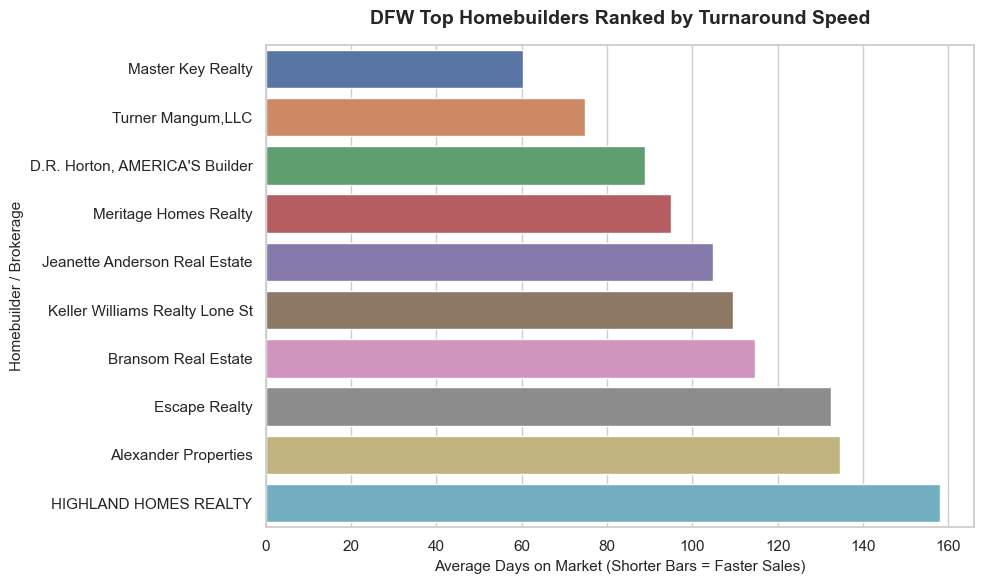

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, professional visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Create a horizontal bar chart mapping speed
sns.barplot(
    x='Avg_Days_On_Market', 
    y=final_builder_dashboard.index, 
    data=final_builder_dashboard,
    hue=final_builder_dashboard.index,
    legend=False
)

# 3. Add clean labels for your editor
plt.title('DFW Top Homebuilders Ranked by Turnaround Speed', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Days on Market (Shorter Bars = Faster Sales)', fontsize=11)
plt.ylabel('Homebuilder / Brokerage', fontsize=11)
plt.tight_layout()

# 4. Display the chart right inside your notebook
plt.show()

In [4]:
# 8. Calculate Global Market Benchmarks (For Context)
overall_market_avg = df['days_on_market'].mean()
overall_market_median = df['days_on_market'].median()

print("--- GLOBAL MARKET BENCHMARKS ---")
print(f"DFW Market Average (All Sales): {overall_market_avg:.1f} days")
print(f"DFW Market Median (All Sales):  {overall_market_median:.1f} days")
print("-" * 32)

# 9. Slice it by Resale vs. New Construction to be even more precise
# Create a temporary flag to split the data
df['is_new_build'] = df['yearBuilt'].isin([2025, 2026])

type_benchmarks = df.groupby('is_new_build')['days_on_market'].agg(['count', 'mean', 'median']).round(1)
type_benchmarks.index = ['Existing Resale', 'New Construction (All Builders)']
type_benchmarks.columns = ['Total Sales', 'Avg Days on Market', 'Median Days on Market']

print("\n--- BENCHMARKS BY PROPERTY TYPE ---")
print(type_benchmarks)

--- GLOBAL MARKET BENCHMARKS ---
DFW Market Average (All Sales): 94.4 days
DFW Market Median (All Sales):  72.0 days
--------------------------------

--- BENCHMARKS BY PROPERTY TYPE ---
                                 Total Sales  Avg Days on Market  \
Existing Resale                        70504                90.9   
New Construction (All Builders)        18953               107.5   

                                 Median Days on Market  
Existing Resale                                   67.0  
New Construction (All Builders)                   93.0  


In [3]:
import pandas as pd

# 1. Load your data
file_name = 'DFW_2026.csv'
df = pd.read_csv(file_name, low_memory=False)

# 2. Fix the dates and calculate "Days on Market"
# The dates in your CSV have a "T" and "Z" (e.g., 2025-10-16T14:11:09.598Z)
# pandas handles this perfectly with to_datetime
df['listingAddedDate'] = pd.to_datetime(df['listingAddedDate'], errors='coerce')
df['lastSoldDate'] = pd.to_datetime(df['lastSoldDate'], errors='coerce')
df['days_on_market'] = (df['lastSoldDate'] - df['listingAddedDate']).dt.days

# 3. Filter strictly for homes built in 2025 and 2026
new_builds_df = df[df['yearBuilt'].isin([2025, 2026])]

# 4. Group by County and calculate Count, Total SqFt, AND Median Days on Market
county_stats = new_builds_df.groupby('County').agg(
    Total_Homes_Sold=('propertyId', 'count'),
    Total_SqFt=('sqft_amount', 'sum'),
    Median_Days_on_Market=('days_on_market', 'median')
).reset_index()

# 5. Sort by the fastest selling counties
county_stats = county_stats.sort_values('Median_Days_on_Market')

# Display the final table
print(county_stats)

       County  Total_Homes_Sold  Total_SqFt  Median_Days_on_Market
1      Dallas              1905   4733744.0                   82.0
0      Collin              5233  12337846.0                   87.0
11    Tarrant              2582   5641288.0                   87.0
4        Hood               332    663072.0                   88.0
7     Kaufman              1400   2837360.0                   89.0
5        Hunt               431    863870.0                   89.0
12       Wise               391    855748.0                   97.0
2      Denton              3335   8036007.0                   97.0
10  Somervell                23     48580.0                   99.0
3       Ellis              1096   2644940.0                  102.0
6     Johnson               882   2032348.0                  104.0
8      Parker               661   1620292.0                  106.0
9    Rockwall               704   1942162.0                  127.0


In [4]:
import pandas as pd

# 1. Load your data
file_name = 'DFW_2026.csv'
df = pd.read_csv(file_name, low_memory=False)

# 2. Fix the dates and calculate "Days on Market"
df['listingAddedDate'] = pd.to_datetime(df['listingAddedDate'], errors='coerce')
df['lastSoldDate'] = pd.to_datetime(df['lastSoldDate'], errors='coerce')
df['days_on_market'] = (df['lastSoldDate'] - df['listingAddedDate']).dt.days

# 3. Filter for comparison group
# OPTION A: Existing Homes (Pre-2025) -> BEST FOR COMPARISON
comparison_df = df[~df['yearBuilt'].isin([2025, 2026])]

# OPTION B: Literally All Homes (If you prefer this, uncomment the line below)
# comparison_df = df.copy()

# 4. Group by County and calculate Count, Total SqFt, AND Median Days on Market
county_stats = comparison_df.groupby('County').agg(
    Total_Homes_Sold=('propertyId', 'count'),
    Total_SqFt=('sqft_amount', 'sum'),
    Median_Days_on_Market=('days_on_market', 'median')
).reset_index()

# 5. Sort by the fastest selling counties
county_stats = county_stats.sort_values('Median_Days_on_Market')

# Display the final table
print(county_stats)

       County  Total_Homes_Sold  Total_SqFt  Median_Days_on_Market
11    Tarrant             18132  39958474.0                   61.0
1      Dallas             16854  35707508.0                   62.0
2      Denton             10685  27324864.0                   66.0
0      Collin             11641  30899450.0                   68.0
6     Johnson              2117   4467797.0                   79.0
3       Ellis              2277   5437982.0                   80.0
8      Parker              2198   5152284.0                   86.0
4        Hood              1036   2192469.0                   87.0
9    Rockwall              1594   4230973.0                   87.5
10  Somervell                82    161826.0                   90.0
12       Wise               809   1714625.0                   91.0
5        Hunt              1086   2148180.0                   96.0
7     Kaufman              2082   4451414.0                   97.0


In [5]:
import pandas as pd

# 1. Load your data
file_name = 'DFW_2026.csv'
df = pd.read_csv(file_name, low_memory=False)

# 2. Calculate the total number of ALL homes sold by County
# (We use .size() here to just count the rows, which represents the number of homes)
all_homes_sold = df.groupby('County').size().reset_index(name='Total_Homes_Sold_ALL')

# 3. Filter for strictly 2025 and 2026 new builds
new_builds_df = df[df['yearBuilt'].isin([2025, 2026])]

# 4. Calculate the total number of NEW homes sold by County
new_builds_sold = new_builds_df.groupby('County').size().reset_index(name='Total_Homes_Sold_25_26')

# 5. Merge the two tables together side-by-side based on the County name
combined_stats = pd.merge(all_homes_sold, new_builds_sold, on='County', how='left')

# 6. Clean up the data (fill any blank counties with 0 for new builds)
combined_stats['Total_Homes_Sold_25_26'] = combined_stats['Total_Homes_Sold_25_26'].fillna(0).astype(int)

# 7. Sort by the counties moving the highest overall volume
combined_stats = combined_stats.sort_values('Total_Homes_Sold_ALL', ascending=False).reset_index(drop=True)

# Display the final table
print(combined_stats)

       County  Total_Homes_Sold_ALL  Total_Homes_Sold_25_26
0     Tarrant                 20714                    2582
1      Dallas                 18759                    1905
2      Collin                 16874                    5233
3      Denton                 14020                    3335
4     Kaufman                  3482                    1400
5       Ellis                  3373                    1096
6     Johnson                  2999                     882
7      Parker                  2859                     661
8    Rockwall                  2298                     704
9        Hunt                  1517                     431
10       Hood                  1368                     332
11       Wise                  1200                     391
12  Somervell                   105                      23


In [7]:
import pandas as pd

# 1. Load your data
file_name = 'DFW_2026.csv'
df = pd.read_csv(file_name, low_memory=False)

# 2. Calculate the total number of ALL homes sold by County and City
all_homes_by_city = df.groupby(['County', 'city']).size().reset_index(name='Total_Homes_Sold_ALL')

# 3. Filter for strictly 2025 and 2026 new builds
new_builds_df = df[df['yearBuilt'].isin([2025, 2026])]

# 4. Calculate the total number of NEW homes sold by County and City
new_builds_by_city = new_builds_df.groupby(['County', 'city']).size().reset_index(name='Total_Homes_Sold_25_26')

# 5. Merge the tables together side-by-side using BOTH County and City as keys
combined_city_stats = pd.merge(all_homes_by_city, new_builds_by_city, on=['County', 'city'], how='left')

# 6. Clean up the data (fill any blank cities with 0 for new builds)
combined_city_stats['Total_Homes_Sold_25_26'] = combined_city_stats['Total_Homes_Sold_25_26'].fillna(0).astype(int)

# 7. Sort: Alphabetically by County, then by highest overall volume within that County
combined_city_stats = combined_city_stats.sort_values(
    by=['County', 'Total_Homes_Sold_ALL'], 
    ascending=[True, False]
).reset_index(drop=True)

# Display the final nested table
print(combined_city_stats)

     County       city  Total_Homes_Sold_ALL  Total_Homes_Sold_25_26
0    Collin   McKinney                  4009                    1421
1    Collin      Plano                  2336                      81
2    Collin  Princeton                  1464                     985
3    Collin     Celina                  1387                     803
4    Collin      Allen                  1294                      70
..      ...        ...                   ...                     ...
279    Wise     Aurora                    16                       1
280    Wise     Sunset                    12                       2
281    Wise       Azle                    11                       3
282    Wise     Justin                     9                       9
283    Wise  Jacksboro                     2                       0

[284 rows x 4 columns]


In [8]:
import pandas as pd

# 1. Load both datasets into the same notebook
df_2025 = pd.read_csv('DFW_2025.csv', low_memory=False)
df_2026 = pd.read_csv('DFW_2026.csv', low_memory=False)

# FIX: Force columns to be capitalized consistently across both datasets
# This ensures 'county' becomes 'County' and 'city' becomes 'City' if they are lowercase
df_2025 = df_2025.rename(columns={'county': 'County', 'city': 'City'})
df_2026 = df_2026.rename(columns={'county': 'County', 'city': 'City'})

# 2. Get 2025 City Aggregates (Now safely using capital 'County' and 'City')
all_2025_city = df_2025.groupby(['County', 'City']).size().reset_index(name='All_Sold_2025')
new_2025_city = df_2025[df_2025['yearBuilt'].isin([2024, 2025])].groupby(['County', 'City']).size().reset_index(name='New_Sold_2025')
stats_2025_city = pd.merge(all_2025_city, new_2025_city, on=['County', 'City'], how='left').fillna(0)

# 3. Get 2026 City Aggregates
all_2026_city = df_2026.groupby(['County', 'City']).size().reset_index(name='All_Sold_2026')
new_2026_city = df_2026[df_2026['yearBuilt'].isin([2025, 2026])].groupby(['County', 'City']).size().reset_index(name='New_Sold_2026')
stats_2026_city = pd.merge(all_2026_city, new_2026_city, on=['County', 'City'], how='left').fillna(0)

# 4. Merge 2025 and 2026 city data together side-by-side
comparison_city_df = pd.merge(stats_2025_city, stats_2026_city, on=['County', 'City'], how='outer').fillna(0)

# 5. Calculate Percentage Changes
comparison_city_df['All_Homes_Pct_Change'] = ((comparison_city_df['All_Sold_2026'] - comparison_city_df['All_Sold_2025']) / comparison_city_df['All_Sold_2025']) * 100
comparison_city_df['New_Builds_Pct_Change'] = ((comparison_city_df['New_Sold_2026'] - comparison_city_df['New_Sold_2025']) / comparison_city_df['New_Sold_2025']) * 100

# Round for cleaner display
comparison_city_df['All_Homes_Pct_Change'] = comparison_city_df['All_Homes_Pct_Change'].round(1)
comparison_city_df['New_Builds_Pct_Change'] = comparison_city_df['New_Builds_Pct_Change'].round(1)

# 6. Sort: Alphabetically by County, then by the highest growth in All Homes within that County
comparison_city_df = comparison_city_df.sort_values(
    by=['County', 'All_Homes_Pct_Change'], 
    ascending=[True, False]
).reset_index(drop=True)

# Display the final nested city comparison table
print(comparison_city_df)

     County          City  All_Sold_2025  New_Sold_2025  All_Sold_2026  \
0    Collin      Campbell            0.0            0.0            4.0   
1    Collin   Duncanville            0.0            0.0            2.0   
2    Collin    Seis Lagos            0.0            0.0           17.0   
3    Collin       St Paul            0.0            0.0            6.0   
4    Collin         Texas            0.0            0.0            1.0   
..      ...           ...            ...            ...            ...   
327    Wise   Runaway Bay           66.0           13.0           44.0   
328    Wise        Justin           14.0           13.0            9.0   
329    Wise    Fort Worth            4.0            3.0            0.0   
330    Wise  New Fairview           37.0           20.0            0.0   
331    Wise     Poolville            3.0            0.0            0.0   

     New_Sold_2026  All_Homes_Pct_Change  New_Builds_Pct_Change  
0              4.0                   inf     

In [6]:
import pandas as pd

# 1. Load both datasets into the same notebook
df_2025 = pd.read_csv('DFW_2025.csv', low_memory=False)
df_2026 = pd.read_csv('DFW_2026.csv', low_memory=False)

# FIX: Force 'county' to be capitalized consistently as 'County'
df_2025 = df_2025.rename(columns={'county': 'County'})
df_2026 = df_2026.rename(columns={'county': 'County'})

# 2. Get 2025 County Aggregates (All Homes vs New Builds)
all_2025_county = df_2025.groupby('County').size().reset_index(name='All_Sold_2025')
new_2025_county = df_2025[df_2025['yearBuilt'].isin([2024, 2025])].groupby('County').size().reset_index(name='New_Sold_2025')
stats_2025_county = pd.merge(all_2025_county, new_2025_county, on='County', how='left').fillna(0)

# 3. Get 2026 County Aggregates (All Homes vs New Builds)
all_2026_county = df_2026.groupby('County').size().reset_index(name='All_Sold_2026')
new_2026_county = df_2026[df_2026['yearBuilt'].isin([2025, 2026])].groupby('County').size().reset_index(name='New_Sold_2026')
stats_2026_county = pd.merge(all_2026_county, new_2026_county, on='County', how='left').fillna(0)

# 4. Merge 2025 and 2026 county data together side-by-side
comparison_county_df = pd.merge(stats_2025_county, stats_2026_county, on='County', how='outer').fillna(0)

# 5. Calculate Year-Over-Year Percentage Changes
comparison_county_df['All_Homes_Pct_Change'] = ((comparison_county_df['All_Sold_2026'] - comparison_county_df['All_Sold_2025']) / comparison_county_df['All_Sold_2025']) * 100
comparison_county_df['New_Builds_Pct_Change'] = ((comparison_county_df['New_Sold_2026'] - comparison_county_df['New_Sold_2025']) / comparison_county_df['New_Sold_2025']) * 100

# Round percentages for clean display
comparison_county_df['All_Homes_Pct_Change'] = comparison_county_df['All_Homes_Pct_Change'].round(1)
comparison_county_df['New_Builds_Pct_Change'] = comparison_county_df['New_Builds_Pct_Change'].round(1)

# 6. Sort by the highest growth in All Homes volume
comparison_county_df = comparison_county_df.sort_values('All_Homes_Pct_Change', ascending=False).reset_index(drop=True)

# Display the final county comparison matrix
print(comparison_county_df)

       County  All_Sold_2025  New_Sold_2025  All_Sold_2026  New_Sold_2026  \
0      Collin          14055           4328          16874           5233   
1   Somervell             90             14            105             23   
2        Hood           1203            288           1368            332   
3        Wise           1123            342           1200            391   
4    Rockwall           2166            672           2298            704   
5      Parker           2752            665           2859            661   
6      Denton          13617           3292          14020           3335   
7       Ellis           3310           1095           3373           1096   
8     Johnson           2952            920           2999            882   
9     Tarrant          20707           2702          20714           2582   
10     Dallas          18846           2028          18759           1905   
11    Kaufman           3571           1636           3482           1400   

In [13]:
# 1. Set a minimum sales threshold for 2025 to filter out small-sample noise
min_sales_2025 = 500

# 2. Filter out 'inf' values and cities below the baseline threshold
filtered_cities = comparison_city_df[
    (comparison_city_df['All_Sold_2025'] >= min_sales_2025) & 
    (comparison_city_df['All_Homes_Pct_Change'] != float('inf'))
]

# 3. Extract the Top 10 Increases
top_10_increases = filtered_cities.sort_values(by='All_Homes_Pct_Change', ascending=False).head(10)

# 4. Extract the Top 10 Decreases
top_10_decreases = filtered_cities.sort_values(by='All_Homes_Pct_Change', ascending=True).head(10)

# Display the results cleanly
print("=================== TOP 10 REAL MARKET INCREASES ===================")
print(top_10_increases[['County', 'City', 'All_Sold_2025', 'All_Sold_2026', 'All_Homes_Pct_Change']].reset_index(drop=True))

print("\n=================== TOP 10 REAL MARKET DECREASES ===================")
print(top_10_decreases[['County', 'City', 'All_Sold_2025', 'All_Sold_2026', 'All_Homes_Pct_Change']].reset_index(drop=True))

=================== TOP 10 REAL MARKET INCREASES ===================
     County      City  All_Sold_2025  All_Sold_2026  All_Homes_Pct_Change
0  Rockwall  Rockwall          749.0         1368.0                  82.6
1    Denton    Argyle          536.0          898.0                  67.5
2    Collin  McKinney         2794.0         4009.0                  43.5
3    Denton    Aubrey          912.0         1295.0                  42.0
4    Collin    Celina          999.0         1387.0                  38.8
5    Collin     Allen          975.0         1294.0                  32.7
6    Collin      Anna          635.0          796.0                  25.4
7    Collin     Wylie          582.0          702.0                  20.6
8   Johnson  Cleburne          656.0          778.0                  18.6
9    Denton    Denton         1458.0         1659.0                  13.8

=================== TOP 10 REAL MARKET DECREASES ===================
     County           City  All_Sold_2025  All_

In [12]:
# 1. Set a minimum threshold for NEW home sales in 2025 to filter out noise
min_new_sales_2025 = 100

# 2. Filter out 'inf' values and cities below the new construction baseline
filtered_new_builds = comparison_city_df[
    (comparison_city_df['New_Sold_2025'] >= min_new_sales_2025) & 
    (comparison_city_df['New_Builds_Pct_Change'] != float('inf'))
]

# 3. Extract the Top 10 Increases for New Construction
new_top_10_increases = filtered_new_builds.sort_values(by='New_Builds_Pct_Change', ascending=False).head(10)

# 4. Extract the Top 10 Decreases for New Construction
new_top_10_decreases = filtered_new_builds.sort_values(by='New_Builds_Pct_Change', ascending=True).head(10)

# Display the final tables cleanly
print("=================== TOP 10 NEW BUILD MARKET INCREASES ===================")
print(new_top_10_increases[['County', 'City', 'New_Sold_2025', 'New_Sold_2026', 'New_Builds_Pct_Change']].reset_index(drop=True))

print("\n=================== TOP 10 NEW BUILD MARKET DECREASES ===================")
print(new_top_10_decreases[['County', 'City', 'New_Sold_2025', 'New_Sold_2026', 'New_Builds_Pct_Change']].reset_index(drop=True))

=================== TOP 10 NEW BUILD MARKET INCREASES ===================
    County        City  New_Sold_2025  New_Sold_2026  New_Builds_Pct_Change
0  Tarrant     Crowley          195.0          652.0                  234.4
1   Collin    McKinney          779.0         1421.0                   82.4
2   Denton      Justin          245.0          435.0                   77.6
3   Collin      Celina          498.0          803.0                   61.2
4   Denton      Denton          263.0          412.0                   56.7
5    Ellis       Ennis          129.0          196.0                   51.9
6  Tarrant      Haslet          133.0          199.0                   49.6
7   Denton      Aubrey          384.0          549.0                   43.0
8    Ellis  Waxahachie          212.0          295.0                   39.2
9  Johnson    Cleburne          209.0          263.0                   25.8

=================== TOP 10 NEW BUILD MARKET DECREASES ===================
     County    

In [14]:
import pandas as pd

# 1. Load both datasets into the same notebook
df_2025 = pd.read_csv('DFW_2025.csv', low_memory=False)
df_2026 = pd.read_csv('DFW_2026.csv', low_memory=False)

# FIX: Force 'county' to be capitalized consistently as 'County'
df_2025 = df_2025.rename(columns={'county': 'County'})
df_2026 = df_2026.rename(columns={'county': 'County'})

# 2. Get 2025 County Aggregates (Total SQFT: All Homes vs New Builds)
# FIX: Swapped .size() to .groupby('County')['sqft_amount'].sum()
all_2025_county = df_2025.groupby('County')['sqft_amount'].sum().reset_index(name='All_Sqft_2025')
new_2025_county = df_2025[df_2025['yearBuilt'].isin([2024, 2025])].groupby('County')['sqft_amount'].sum().reset_index(name='New_Sqft_2025')
stats_2025_county = pd.merge(all_2025_county, new_2025_county, on='County', how='left').fillna(0)

# 3. Get 2026 County Aggregates (Total SQFT: All Homes vs New Builds)
# FIX: Swapped .size() to .groupby('County')['sqft_amount'].sum()
all_2026_county = df_2026.groupby('County')['sqft_amount'].sum().reset_index(name='All_Sqft_2026')
new_2026_county = df_2026[df_2026['yearBuilt'].isin([2025, 2026])].groupby('County')['sqft_amount'].sum().reset_index(name='New_Sqft_2026')
stats_2026_county = pd.merge(all_2026_county, new_2026_county, on='County', how='left').fillna(0)

# 4. Merge 2025 and 2026 county data together side-by-side
comparison_county_df = pd.merge(stats_2025_county, stats_2026_county, on='County', how='outer').fillna(0)

# 5. Calculate Year-Over-Year Percentage Changes based on Total Square Footage
comparison_county_df['All_Sqft_Pct_Change'] = ((comparison_county_df['All_Sqft_2026'] - comparison_county_df['All_Sqft_2025']) / comparison_county_df['All_Sqft_2025']) * 100
comparison_county_df['New_Sqft_Pct_Change'] = ((comparison_county_df['New_Sqft_2026'] - comparison_county_df['New_Sqft_2025']) / comparison_county_df['New_Sqft_2025']) * 100

# Round percentages for clean display
comparison_county_df['All_Sqft_Pct_Change'] = comparison_county_df['All_Sqft_Pct_Change'].round(1)
comparison_county_df['New_Sqft_Pct_Change'] = comparison_county_df['New_Sqft_Pct_Change'].round(1)

# 6. Sort by the highest growth in Total Square Footage volume
comparison_county_df = comparison_county_df.sort_values('All_Sqft_Pct_Change', ascending=False).reset_index(drop=True)

# Display the final county comparison matrix
print(comparison_county_df)

       County  All_Sqft_2025  New_Sqft_2025  All_Sqft_2026  New_Sqft_2026  \
0      Collin     36143750.0     10281446.0     43237296.0     12337846.0   
1        Hood      2508812.0       546972.0      2855541.0       663072.0   
2        Wise      2357799.0       757241.0      2570373.0       855748.0   
3    Rockwall      5695084.0      1695657.0      6173135.0      1942162.0   
4   Somervell       195708.0        29582.0       210406.0        48580.0   
5      Parker      6443984.0      1585541.0      6772576.0      1620292.0   
6       Ellis      7827864.0      2690726.0      8082922.0      2644940.0   
7      Denton     34471487.0      8256833.0     35360871.0      8036007.0   
8      Dallas     39670573.0      4850998.0     40441252.0      4733744.0   
9     Tarrant     45116325.0      6023132.0     45599762.0      5641288.0   
10    Johnson      6478335.0      2140189.0      6500145.0      2032348.0   
11    Kaufman      7465149.0      3338408.0      7288774.0      2837360.0   

In [16]:
import pandas as pd

# 1. Load both datasets
df_2025 = pd.read_csv('DFW_2025.csv', low_memory=False)
df_2026 = pd.read_csv('DFW_2026.csv', low_memory=False)

# Force 'county' and 'city' to be capitalized consistently
df_2025 = df_2025.rename(columns={'county': 'County', 'city': 'City'})
df_2026 = df_2026.rename(columns={'county': 'County', 'city': 'City'})

# 2. Get 2025 City Aggregates (Total SQFT: All Homes vs New Builds)
all_2025_city = df_2025.groupby(['County', 'City'])['sqft_amount'].sum().reset_index(name='All_Sqft_2025')
new_2025_city = df_2025[df_2025['yearBuilt'].isin([2024, 2025])].groupby(['County', 'City'])['sqft_amount'].sum().reset_index(name='New_Sqft_2025')
stats_2025_city = pd.merge(all_2025_city, new_2025_city, on=['County', 'City'], how='left').fillna(0)

# 3. Get 2026 City Aggregates (Total SQFT: All Homes vs New Builds)
all_2026_city = df_2026.groupby(['County', 'City'])['sqft_amount'].sum().reset_index(name='All_Sqft_2026')
new_2026_city = df_2026[df_2026['yearBuilt'].isin([2025, 2026])].groupby(['County', 'City'])['sqft_amount'].sum().reset_index(name='New_Sqft_2026')
stats_2026_city = pd.merge(all_2026_city, new_2026_city, on=['County', 'City'], how='left').fillna(0)

# 4. Merge 2025 and 2026 city data together side-by-side
comparison_city_df = pd.merge(stats_2025_city, stats_2026_city, on=['County', 'City'], how='outer').fillna(0)

# 5. Calculate Year-Over-Year Percentage Changes based on Total Square Footage
comparison_city_df['All_Sqft_Pct_Change'] = ((comparison_city_df['All_Sqft_2026'] - comparison_city_df['All_Sqft_2025']) / comparison_city_df['All_Sqft_2025']) * 100
comparison_city_df['New_Sqft_Pct_Change'] = ((comparison_city_df['New_Sqft_2026'] - comparison_city_df['New_Sqft_2025']) / comparison_city_df['New_Sqft_2025']) * 100

# Round percentages for clean display
comparison_city_df['All_Sqft_Pct_Change'] = comparison_city_df['All_Sqft_Pct_Change'].round(1)
comparison_city_df['New_Sqft_Pct_Change'] = comparison_city_df['New_Sqft_Pct_Change'].round(1)


# =====================================================================
# FILTER AND RANKING LOGIC (The part that threw the error)
# =====================================================================

# 1. Set a minimum total square footage threshold for 2025 to filter out small-sample noise
min_sqft_2025 = 1000000 

# 2. Filter out 'inf' values and cities below the square footage baseline threshold
filtered_cities = comparison_city_df[
    (comparison_city_df['All_Sqft_2025'] >= min_sqft_2025) & 
    (comparison_city_df['All_Sqft_Pct_Change'] != float('inf'))
]

# 3. Extract the Top 10 Increases in Square Footage Volume
top_10_increases = filtered_cities.sort_values(by='All_Sqft_Pct_Change', ascending=False).head(10)

# 4. Extract the Top 10 Decreases in Square Footage Volume
top_10_decreases = filtered_cities.sort_values(by='All_Sqft_Pct_Change', ascending=True).head(10)

# Display the results cleanly
print("=================== TOP 10 REAL SQFT MARKET INCREASES ===================")
print(top_10_increases[['County', 'City', 'All_Sqft_2025', 'All_Sqft_2026', 'All_Sqft_Pct_Change']].reset_index(drop=True))

print("\n=================== TOP 10 REAL SQFT MARKET DECREASES ===================")
print(top_10_decreases[['County', 'City', 'All_Sqft_2025', 'All_Sqft_2026', 'All_Sqft_Pct_Change']].reset_index(drop=True))

=================== TOP 10 REAL SQFT MARKET INCREASES ===================
     County      City  All_Sqft_2025  All_Sqft_2026  All_Sqft_Pct_Change
0   Tarrant   Crowley      1012477.0      2353178.0                132.4
1  Rockwall  Rockwall      2004442.0      4007406.0                 99.9
2    Denton    Argyle      1548921.0      2696798.0                 74.1
3    Denton    Aubrey      2085435.0      2955737.0                 41.7
4    Collin  McKinney      7199599.0     10156080.0                 41.1
5    Parker     Aledo      1305345.0      1837375.0                 40.8
6    Collin     Allen      2570494.0      3602849.0                 40.2
7    Collin    Celina      3000808.0      3975944.0                 32.5
8    Collin      Anna      1407996.0      1807843.0                 28.4
9    Collin     Wylie      1403361.0      1757323.0                 25.2

=================== TOP 10 REAL SQFT MARKET DECREASES ===================
     County           City  All_Sqft_2025  All_S

In [21]:
# 1. Set a minimum threshold for NEW home square footage in 2025 to filter out noise
# 250,000 sq ft is roughly equivalent to 100 new construction homes.
min_new_sqft_2025 = 500000

# 2. Filter out 'inf' values and cities below the new construction baseline
filtered_new_builds = comparison_city_df[
    (comparison_city_df['New_Sqft_2025'] >= min_new_sqft_2025) & 
    (comparison_city_df['New_Sqft_Pct_Change'] != float('inf'))
]

# 3. Extract the Top 10 Increases for New Construction Square Footage
new_top_10_increases = filtered_new_builds.sort_values(by='New_Sqft_Pct_Change', ascending=False).head(10)

# 4. Extract the Top 10 Decreases for New Construction Square Footage
new_top_10_decreases = filtered_new_builds.sort_values(by='New_Sqft_Pct_Change', ascending=True).head(10)

# Display the final tables cleanly
print("=================== TOP 10 NEW BUILD SQFT INCREASES ===================")
print(new_top_10_increases[['County', 'City', 'New_Sqft_2025', 'New_Sqft_2026', 'New_Sqft_Pct_Change']].reset_index(drop=True))

print("\n=================== TOP 10 NEW BUILD SQFT DECREASES ===================")
print(new_top_10_decreases[['County', 'City', 'New_Sqft_2025', 'New_Sqft_2026', 'New_Sqft_Pct_Change']].reset_index(drop=True))

=================== TOP 10 NEW BUILD SQFT INCREASES ===================
   County        City  New_Sqft_2025  New_Sqft_2026  New_Sqft_Pct_Change
0  Denton      Justin       525211.0      1047467.0                 99.4
1  Collin    McKinney      1937347.0      3480170.0                 79.6
2  Denton      Denton       583725.0       945672.0                 62.0
3  Collin      Celina      1538667.0      2205218.0                 43.3
4   Ellis  Waxahachie       562435.0       754119.0                 34.1
5  Denton      Aubrey       912378.0      1204308.0                 32.0
6  Collin        Anna       776343.0       878852.0                 13.2
7  Dallas    Mesquite       509255.0       556544.0                  9.3
8  Dallas      Dallas      2336018.0      2522286.0                  8.0
9  Denton     Prosper       517028.0       537082.0                  3.9

=================== TOP 10 NEW BUILD SQFT DECREASES ===================
     County        City  New_Sqft_2025  New_Sqft_202